In [44]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, classification_report

# Exploration : Arbre de décision CART et Forêt Aléatoire (données SAh)
**Données** : `dfbase.csv` — données SAh préparées (variables encodées, cible = `chd` → renommée `Y`)  
**Plan** :
1. Arbre de décision CART (`DecisionTreeClassifier`, critère Gini) + visualisation
2. Forêt aléatoire (`RandomForestClassifier`, 300 arbres) + évaluation  
> Note : ici on ajuste sur tout l'échantillon (pas de CV). Pour une comparaison rigoureuse, voir `ComparaisonCS_final.ipynb`.

In [65]:
don = pd.read_csv("dfbase.csv", header=0, sep=",")
don.head(3)

,famhist[T.Present],adiposity,age,alcohol,ldl,obesity,sbp,tobacco,typea,Y
0,1.0,23.11,52.0,97.20,5.73,25.30,160.0,12.00,49.0,1
1,0.0,28.61,63.0,2.06,4.41,28.87,144.0,0.01,55.0,1
2,1.0,32.28,46.0,3.81,3.48,29.14,118.0,0.08,52.0,0


In [ ]:
# Renommage de chd→Y et extraction de X (DataFrame) et Y (numpy)
don = don.rename(columns={"chd": "Y"})
X = don.drop(columns=["Y"])      # X garde les noms de colonnes (utile pour visualiser l'arbre)
Y = don["Y"].to_numpy()

Entraîner un arbre de décision CART

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Arbre CART : criterion="gini" → minimise l'impureté de Gini à chaque nœud
# max_depth=10 : profondeur maximale (limiter pour éviter le surapprentissage)
# min_samples_split=10 : au moins 10 individus dans un nœud pour le couper
modele = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,
    min_samples_split=10
)
modele.fit(X, Y)

DecisionTreeClassifier(max_depth=10, min_samples_split=10)

Visualisation de l'arbre

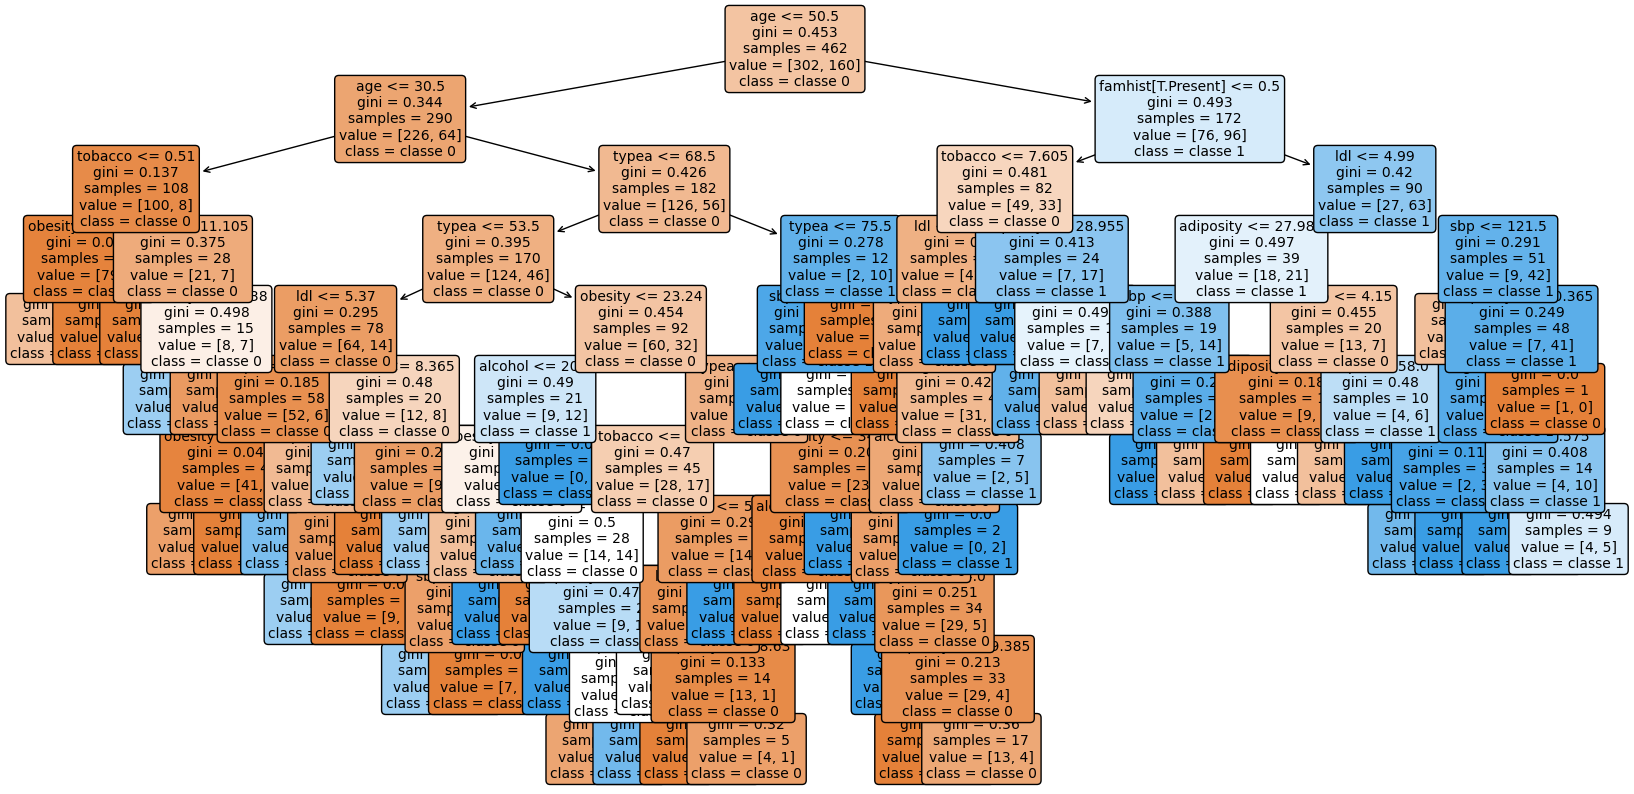

In [80]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(
    modele,
    feature_names=X.columns,
    class_names=["classe 0", "classe 1"],
    filled=True,
    rounded=True,
    fontsize = 10
)
plt.show()


Modèle Forêt Aléatoire

In [ ]:
# Forêt aléatoire : 300 arbres construits sur des sous-échantillons bootstrap
# n_jobs=-1 : utilise tous les cœurs CPU disponibles pour aller plus vite
# random_state=42 : reproductibilité
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,     # arbres complets (pas de limite de profondeur)
    random_state=42,
    n_jobs=-1
)
rf.fit(X, Y)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
# Évaluation sur l'échantillon d'apprentissage (= optimiste car pas de CV !)
y_pred = rf.predict(X)
print("Accuracy (sur apprentissage) :", accuracy_score(Y, y_pred))
print(classification_report(Y, y_pred))
# → Les scores seront meilleurs ici que sur données test : biais d'optimisme de la forêt complète

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       302
           1       1.00      1.00      1.00       160

    accuracy                           1.00       462
   macro avg       1.00      1.00      1.00       462
weighted avg       1.00      1.00      1.00       462

